In [179]:
# Basic setup and environment check
# This verifies that Jupyter is properly installed and accessible
import jupyter

print(f"Jupyter version: {jupyter.__spec__}")



Jupyter version: ModuleSpec(name='jupyter', loader=<_frozen_importlib_external.SourceFileLoader object at 0x10465bb90>, origin='/Users/ole-michael.ekornrud/Documents/Workspace/CSIC-LLM-Prompting/.venv/lib/python3.13/site-packages/jupyter.py')


In [180]:
# DATA LOADING AND INITIAL EXPLORATION
# ====================================
# Load customer service tweet dataset for intent classification analysis

import pandas as pd 

# Configure pandas display options for better readability in notebook
# This prevents dataframe wrapping when it's too wide for console output
pd.set_option('display.expand_frame_repr', False)

# Load the customer service tweet dataset
# Dataset contains conversations between customers and support teams
# Key columns: tweet_id, author_id, inbound, text, response_tweet_id
# Load full dataset
df = pd.read_csv('../data/raw/twcs.csv')

# Take random sample for parameter tuning
#df = df_full.sample(n=500000, random_state=42)

# Display first 5 rows to understand data structure
print("Dataset Overview:")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())


Dataset Overview:
Shape: (2811774, 7)

First 5 rows:
   tweet_id   author_id  inbound                      created_at                                               text response_tweet_id  in_response_to_tweet_id
0         1  sprintcare    False  Tue Oct 31 22:10:47 +0000 2017  @115712 I understand. I would like to assist y...                 2                      3.0
1         2      115712     True  Tue Oct 31 22:11:45 +0000 2017      @sprintcare and how do you propose we do that               NaN                      1.0
2         3      115712     True  Tue Oct 31 22:08:27 +0000 2017  @sprintcare I have sent several private messag...                 1                      4.0
3         4  sprintcare    False  Tue Oct 31 21:54:49 +0000 2017  @115712 Please send us a Private Message so th...                 3                      5.0
4         5      115712     True  Tue Oct 31 21:49:35 +0000 2017                                 @sprintcare I did.                 4                   

In [181]:
# DATA FILTERING: Focus on customer complaints/requests only
# ========================================================
# Filter dataset to include only inbound tweets (customer requests/complaints)
# inbound=True: Customer tweets TO support accounts (what we want to classify)
# inbound=False: Support responses FROM brands (not needed for intent analysis)

# Use .copy() to create an independent dataframe and avoid SettingWithCopyWarning
df_inbound = df[df["inbound"]].copy()

print(f"Total tweets: {len(df)}")
print(f"Customer tweets (inbound=True): {len(df_inbound)}")
print(f"Support responses (inbound=False): {len(df[~df['inbound']])}")
print("\nSample customer tweets:")
print(df_inbound.head())

Total tweets: 2811774
Customer tweets (inbound=True): 1537843
Support responses (inbound=False): 1273931

Sample customer tweets:
   tweet_id author_id  inbound                      created_at                                               text response_tweet_id  in_response_to_tweet_id
1         2    115712     True  Tue Oct 31 22:11:45 +0000 2017      @sprintcare and how do you propose we do that               NaN                      1.0
2         3    115712     True  Tue Oct 31 22:08:27 +0000 2017  @sprintcare I have sent several private messag...                 1                      4.0
4         5    115712     True  Tue Oct 31 21:49:35 +0000 2017                                 @sprintcare I did.                 4                      6.0
6         8    115712     True  Tue Oct 31 21:45:10 +0000 2017          @sprintcare is the worst customer service            9,6,10                      NaN
8        12    115713     True  Tue Oct 31 22:04:47 +0000 2017  @sprintcare You gonna

In [182]:
# TEXT PREPROCESSING: Clean tweets for TF-IDF analysis
# ==================================================
# Remove noise from tweet text to improve clustering quality
import re

def clean_text(text):
    if pd.isna(text):
        return ""
    
    text = str(text).lower()
    text = re.sub(r'@\w+', '', text)                     # Remove @mentions
    text = re.sub(r'http\S+|www\S+', '', text)           # Remove URLs
    text = re.sub(r'#\w+', '', text)                     # Remove hashtags
    text = re.sub(r'\d+', 'NUMBER', text)                # Replace numbers with token
    text = re.sub(r'[^a-z\s]', ' ', text)                # Remove special chars
    text = re.sub(r'\b\w{1,2}\b', '', text)              # Remove very short words
    text = re.sub(r'\s+', ' ', text).strip()             # Normalize whitespace
    
    return text

# Apply cleaning using .loc to avoid pandas copy warning
# This ensures we're modifying the original dataframe, not a copy
df_inbound.loc[:, 'text'] = df_inbound['text'].astype(str).apply(clean_text)

print(f"Tweets before removing empty ones: {len(df_inbound)}")

# Remove empty tweets
df_inbound = df_inbound[df_inbound['text'].str.len() > 5].copy()
print(f"Tweets after removing empty ones: {len(df_inbound)}")



Tweets before removing empty ones: 1537843
Tweets after removing empty ones: 1476180
Tweets after removing empty ones: 1476180


Creating TF-IDF features...
Current memory usage: 2754.00 MB
Transforming text to TF-IDF matrix...
Operation took 6.30 seconds
TF-IDF matrix shape: (1476180, 3000)
TF-IDF matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Matrix memory: 35.7 MB
Current memory usage: 3011.45 MB

Dataset size: 1,476,180
LARGE DATASET MODE: batch_size=10000, K_range=[5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

Testing 11 different cluster counts...
--------------------
Progress: 1/11 - Testing K=5...
Operation took 1.08 seconds
  Calculating silhouette score...
  K=5: Inertia=1419730.0, Silhouette=0.010
--------------------
Progress: 2/11 - Testing K=6...
Operation took 1.13 seconds
  Calculating silhouette score...
  K=6: Inertia=1415108.2, Silhouette=0.012
Current memory usage: 3134.97 MB
--------------------
Progress: 3/11 - Testing K=7...
Operation took 1.17 seconds
  Calculating silhouette score...
  K=7: Inertia=1405361.8, Silhouette=0.016
--------------------
Progress: 4/11 - Testing K=8...
Operation 

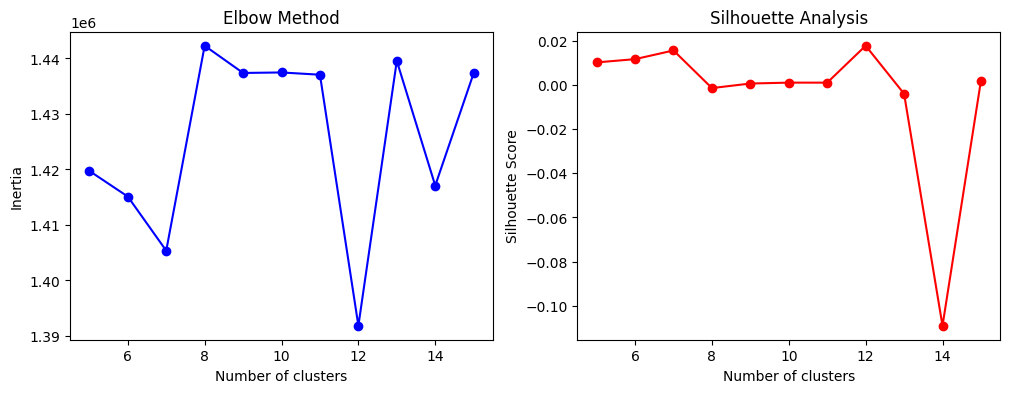


Clustering analysis complete!
Current memory usage: 3159.48 MB

Best silhouette score: 0.018 at K=12


In [196]:
# TF-IDF VECTORIZATION AND CLUSTERING ANALYSIS - OPTIMIZED FOR LARGE DATASETS
# ============================================================================
# Convert text to numerical features and find optimal number of clusters

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np
import psutil
import time
import gc  # Garbage collection for memory management

# Memory monitoring functions

def monitor_memory():
    """Monitor current memory usage"""
    process = psutil.Process()
    memory_mb = process.memory_info().rss / 1024 / 1024
    print(f"Current memory usage: {memory_mb:.2f} MB")
    return memory_mb

def time_operation(func, *args, **kwargs):
    """Time how long an operation takes"""
    start_time = time.time()
    result = func(*args, **kwargs)
    end_time = time.time()
    print(f"Operation took {end_time - start_time:.2f} seconds")
    return result

def free_memory():
    """Force garbage collection to free memory"""
    gc.collect()

# Create TF-IDF features with memory optimization
print("Creating TF-IDF features...")
monitor_memory()

# OPTIMIZED TF-IDF for large datasets
tfidf = TfidfVectorizer(
    max_features=8000,       # REDUCED: Less features = less memory (was 5000)
    ngram_range=(1,2),       # Keep single words only
    min_df=10,               # INCREASED: Ignore rare words (was 20, now 50)
    max_df=0.85,             # INCREASED: Remove very common words (was 0.9)
    stop_words='english',
    lowercase=True,
    strip_accents='ascii',
    dtype=np.float32,         # ADDED: Use 32-bit instead of 64-bit (halves memory)
    sublinear_tf=True
)

# Transform with progress monitoring
print("Transforming text to TF-IDF matrix...")
tfidf_matrix = time_operation(tfidf.fit_transform, df_inbound['text'])
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"TF-IDF matrix type: {type(tfidf_matrix)}")
print(f"Matrix memory: {tfidf_matrix.data.nbytes / 1024 / 1024:.1f} MB")
monitor_memory()

# DATASET SIZE ADAPTIVE CONFIGURATION
dataset_size = len(df_inbound)
print(f"\nDataset size: {dataset_size:,}")

# Configure based on actual dataset size
if dataset_size > 1000000:  # 1M+ rows
    use_minibatch = True
    batch_size = min(10000, dataset_size // 100)  # Dynamic batch size
    K_range = range(5, 16)  # REDUCED range for large datasets
    silhouette_sample = 5000  # Smaller sample for silhouette
    print(f"LARGE DATASET MODE: batch_size={batch_size}, K_range={list(K_range)}")
elif dataset_size > 100000:  # 100K-1M rows  
    use_minibatch = True
    batch_size = 5000
    K_range = range(5, 21)
    silhouette_sample = 8000
    print(f"MEDIUM DATASET MODE: batch_size={batch_size}")
else:  # < 100K rows
    use_minibatch = False
    K_range = range(5, 25)
    silhouette_sample = min(10000, dataset_size)
    print("SMALL DATASET MODE: Using regular KMeans")

# FIND OPTIMAL NUMBER OF CLUSTERS
inertias = []
silhouette_scores = []

print(f"\nTesting {len(K_range)} different cluster counts...")
for i, k in enumerate(K_range):
    print('-' * 20)
    print(f"Progress: {i+1}/{len(K_range)} - Testing K={k}...")
    
    # Choose clustering algorithm
    if use_minibatch:
        kmeans = MiniBatchKMeans(
            n_clusters=k,
            random_state=42,
            batch_size=batch_size,        # OPTIMIZED: Dynamic batch size
            n_init=5,                     # REDUCED: Fewer initializations (was 10)
            max_iter=100,                 # REDUCED: Fewer iterations (was 300)
            init_size=3*batch_size,       # ADDED: Proper init size
            reassignment_ratio=0.01       # ADDED: Faster convergence
        )
    else:
        kmeans = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=5,                     # REDUCED for speed
            max_iter=100,                 # REDUCED for speed
            algorithm='lloyd'
        )
    
    # Fit clustering model
    labels = time_operation(kmeans.fit_predict, tfidf_matrix)
    inertias.append(kmeans.inertia_)
    
    # Calculate silhouette score with aggressive sampling
    print(f"  Calculating silhouette score...")
    sample_indices = np.random.choice(dataset_size, silhouette_sample, replace=False)
    silh_score = silhouette_score(
        tfidf_matrix[sample_indices], 
        labels[sample_indices]
    )
    silhouette_scores.append(silh_score)
    
    print(f"  K={k}: Inertia={kmeans.inertia_:.1f}, Silhouette={silh_score:.3f}")
    
    # Memory management for large datasets
    if use_minibatch and k % 3 == 0:
        monitor_memory()
        free_memory()

# Plot results
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, 'ro-')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.show()

print("\nClustering analysis complete!")
monitor_memory()

# Display results summary
print(f"\nBest silhouette score: {max(silhouette_scores):.3f} at K={K_range[np.argmax(silhouette_scores)]}")

In [197]:
# MULTI-CRITERIA SCORING: More sophisticated approach
# ===================================================

def calculate_comprehensive_scores(K_range, inertias, silhouette_scores):
    """Calculate scores using multiple criteria with different approaches"""
    
    scores = []
    
    for i, k in enumerate(K_range):
        
        # 1. Silhouette quality (normalized 0-1)
        silhouette_norm = (silhouette_scores[i] - min(silhouette_scores)) / \
                         (max(silhouette_scores) - min(silhouette_scores))
        
        # 2. Inertia improvement (how much better than previous)
        if i == 0:
            inertia_improvement = 0
        else:
            inertia_improvement = (inertias[i-1] - inertias[i]) / inertias[i-1]
        
        # 3. Business practicality score
        if 6 <= k <= 12:      # Sweet spot for customer service
            practicality = 1.0
        elif 5 <= k <= 15:    # Acceptable range
            practicality = 0.8
        else:                 # Outside recommended range
            practicality = 0.3
        
        # 4. Stability score (avoid too many clusters for small datasets)
        min_cluster_size = len(df_inbound) / k  # Average cluster size
        if min_cluster_size >= 50:    # Each cluster has at least 50 tweets
            stability = 1.0
        elif min_cluster_size >= 20:
            stability = 0.7
        else:
            stability = 0.3
        
        # Combined score with different weighting strategy
        overall_score = (
            0.3 * silhouette_norm +      # Cluster quality
            0.2 * inertia_improvement +  # Elbow method
            0.3 * practicality +         # Business sense
            0.2 * stability              # Statistical stability
        )
        
        scores.append({
            'k': k,
            'silhouette_norm': silhouette_norm,
            'inertia_improvement': inertia_improvement,
            'practicality': practicality,
            'stability': stability,
            'overall_score': overall_score
        })
    
    return scores

# Calculate comprehensive scores
comp_scores = calculate_comprehensive_scores(K_range, inertias, silhouette_scores)

# Display results
print("K\tSilh\tInertia\tPract\tStab\tOverall")
print("-" * 50)
for score in comp_scores:
    print(f"{score['k']}\t{score['silhouette_norm']:.3f}\t{score['inertia_improvement']:.3f}\t"
          f"{score['practicality']:.3f}\t{score['stability']:.3f}\t{score['overall_score']:.3f}")

# Find best K
best_comp_score = max(comp_scores, key=lambda x: x['overall_score'])
print(f"\nBest K using comprehensive scoring: {best_comp_score['k']}")

K	Silh	Inertia	Pract	Stab	Overall
--------------------------------------------------
5	0.940	0.000	0.800	1.000	0.722
6	0.952	0.003	1.000	1.000	0.786
7	0.983	0.007	1.000	1.000	0.796
8	0.849	-0.026	1.000	1.000	0.749
9	0.865	0.003	1.000	1.000	0.760
10	0.868	-0.000	1.000	1.000	0.760
11	0.868	0.000	1.000	1.000	0.760
12	1.000	0.031	1.000	1.000	0.806
13	0.828	-0.034	0.800	1.000	0.682
14	0.000	0.016	0.800	1.000	0.443
15	0.875	-0.014	0.800	1.000	0.700

Best K using comprehensive scoring: 12


In [198]:
# APPLY FINAL CLUSTERING WITH CHOSEN K VALUE
# ==========================================
# Based on elbow/silhouette analysis, apply KMeans with optimal number of clusters

optimal_k = best_comp_score['k']  # Chosen based on analysis above (adjust if needed)


# Create final clustering model with chosen K
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42)
cluster_labels = final_kmeans.fit_predict(tfidf_matrix)  # Fix typo: was 'tdidf_matrix'

# Add cluster assignments to our dataframe
# Each tweet now has a cluster number (0 to optimal_k-1)
df_inbound.loc[:, 'cluster'] = cluster_labels

print(f"optimal_k type : {type(optimal_k)}")
print(f"final_kmeans type : {type(final_kmeans)}")


# Show distribution of tweets across clusters
print("Cluster sizes:")
print(df_inbound['cluster'].value_counts().sort_index())
print(f"\nTotal tweets clustered: {len(df_inbound)}")


optimal_k type : <class 'int'>
final_kmeans type : <class 'sklearn.cluster._kmeans.KMeans'>
Cluster sizes:
cluster
0     914521
1      53267
2      53760
3      15377
4      57560
5      31619
6      68971
7      36903
8      59969
9      98659
10     49927
11     35647
Name: count, dtype: int64

Total tweets clustered: 1476180


In [186]:
# CLUSTER ANALYSIS: Examine top terms for each cluster
# ===================================================
# This analysis reveals what words/phrases define each cluster
# helping us understand what types of customer issues each cluster represents

def get_top_features_per_cluster(tfidf_matrix, cluster_labels, feature_names, n_features=10):
    """
    Get top TF-IDF features for each cluster
    
    How it works:
    1. KMeans creates cluster centers (centroids) in TF-IDF space
    2. Each centroid shows the "average" word importance for that cluster
    3. We extract the highest-scoring words for each centroid
    4. These top words reveal the theme/intent of each cluster
    """
    cluster_centers = final_kmeans.cluster_centers_

    for cluster_id in range(optimal_k):
        print(f"\n=== CLUSTER {cluster_id + 1} ===")

        # Get top features for this cluster center
        # argsort()[-n_features:][::-1] gets indices of highest scores in descending order
        top_indices = cluster_centers[cluster_id].argsort()[-n_features:][::-1]
        top_features = [feature_names[i] for i in top_indices]
        top_scores = [cluster_centers[cluster_id][i] for i in top_indices]

        print("Top terms (words that define this cluster):")
        for feature, score in zip(top_features, top_scores):
            print(f"    {feature} : {score:.3f}")

# Get the vocabulary (feature names) from our TF-IDF vectorizer
feature_names = tfidf.get_feature_names_out()
get_top_features_per_cluster(tfidf_matrix, cluster_labels, feature_names)  # Fix typo: was 'tdidf_matrix'


=== CLUSTER 1 ===
Top terms (words that define this cluster):
    thank : 0.696
    sent : 0.024
    okay : 0.016
    great : 0.016
    just : 0.013
    help : 0.013
    yes : 0.012
    response : 0.010
    reply : 0.009
    worked : 0.009

=== CLUSTER 2 ===
Top terms (words that define this cluster):
    thanks : 0.024
    just : 0.016
    time : 0.010
    flight : 0.010
    amazon : 0.009
    like : 0.009
    fix : 0.008
    did : 0.008
    amp : 0.008
    need : 0.007

=== CLUSTER 3 ===
Top terms (words that define this cluster):
    don : 0.078
    got : 0.064
    order : 0.061
    day : 0.055
    delivery : 0.045
    just : 0.022
    delivered : 0.018
    today : 0.016
    time : 0.016
    know : 0.016

=== CLUSTER 4 ===
Top terms (words that define this cluster):
    service : 0.233
    customer : 0.117
    worst : 0.024
    just : 0.015
    great : 0.014
    time : 0.014
    poor : 0.013
    terrible : 0.013
    internet : 0.012
    amp : 0.012

=== CLUSTER 5 ===
Top terms (wor

In [187]:
# CLUSTER CONTENT EXAMINATION: View actual tweets in each cluster
# ==============================================================
# After seeing the top terms, examine real tweet examples to understand cluster themes

def examine_cluster_tweets(df, cluster_id, n_samples=5):
    """
    Show sample tweets from a specific cluster
    
    This helps validate our clustering results by showing actual customer tweets
    that were grouped together. We can see if the clustering makes intuitive sense
    and assign appropriate intent labels based on the content.
    """
    cluster_tweets = df[df['cluster'] == cluster_id]
    print(f"\n=== CLUSTER {cluster_id + 1} EXAMPLES (Size: {len(cluster_tweets)}) ===")
    
    for i, (idx, row) in enumerate(cluster_tweets.head(n_samples).iterrows()):
        print(f"{i+1}. {row['text']}")
        print()

# Examine all clusters to understand what customer issues each represents
for cluster_id in range(optimal_k):
    examine_cluster_tweets(df_inbound, cluster_id)


=== CLUSTER 1 EXAMPLES (Size: 21658) ===
1. brilliant thank you

2. thank you very much

3. thank you nike

4. okey thank you

5. sent and thank you


=== CLUSTER 2 EXAMPLES (Size: 1024749) ===
1. and how you propose that

2. have sent several private messages and one responding usual

3. you gonna magically change your connectivity for and whole family

4. all lie about your great connection bars lte still won load something smh

5. whenever contact customer support they tell have shortcode enabled account but have never the years tried


=== CLUSTER 3 EXAMPLES (Size: 149771) ===
1. since signed with you since day

2. picture pretty much every day why should pay per month

3. finally got someone that helped thanks

4. don know router downstairs but just the wifi nothing connected ethernet

5. don fit veggie burrito costume


=== CLUSTER 4 EXAMPLES (Size: 74135) ===
1. the worst customer service

2. your customer service reps are super nice but imma start trippin all don get service g

In [188]:
# CLUSTER-TO-INTENT ANALYSIS: Map 24 clusters to 8 business intents
# ================================================================
# Add this cell to analyze what each of the 24 clusters contains

# First, let's see what the 24 clusters actually contain
print("=== ANALYZING ALL 24 CLUSTERS ===")
for cluster_id in range(optimal_k):
    cluster_tweets = df_inbound[df_inbound['cluster'] == cluster_id]
    print(f"\nCLUSTER {cluster_id} ({len(cluster_tweets)} tweets):")
    
    # Show top 3 tweets and top 5 words for each cluster
    for i, tweet in enumerate(cluster_tweets['text'].head(3)):
        print(f"  {i+1}. {tweet}")
    
    # Show top terms for this cluster
    if len(cluster_tweets) > 0:
        cluster_center = final_kmeans.cluster_centers_[cluster_id]
        top_indices = cluster_center.argsort()[-5:][::-1]
        top_features = [feature_names[i] for i in top_indices]
        print(f"  Top words: {', '.join(top_features)}")
    print("-" * 50)

=== ANALYZING ALL 24 CLUSTERS ===

CLUSTER 0 (21658 tweets):
  1. brilliant thank you
  2. thank you very much
  3. thank you nike
  Top words: thank, sent, okay, great, just
--------------------------------------------------

CLUSTER 1 (1024749 tweets):
  1. and how you propose that
  2. have sent several private messages and one responding usual
  3. you gonna magically change your connectivity for and whole family
  Top words: thanks, just, time, flight, amazon
--------------------------------------------------

CLUSTER 2 (149771 tweets):
  1. since signed with you since day
  2. picture pretty much every day why should pay per month
  3. finally got someone that helped thanks
  Top words: don, got, order, day, delivery
--------------------------------------------------

CLUSTER 3 (74135 tweets):
  1. the worst customer service
  2. your customer service reps are super nice but imma start trippin all don get service going
  3. somebody from please help meeeeee having the worst luck 

In [189]:
# INTENT LABELING: Assign meaningful business labels to clusters
# =============================================================
# After analyzing cluster terms and tweet examples, map each cluster to a business intent
# These labels make the clusters actionable for customer service teams

# DYNAMIC INTENT MAPPING: Adapts to your optimal_k value
# ======================================================
print(f"Creating intent mapping for {optimal_k} clusters")

# Map cluster numbers to meaningful intent categories
# This mapping now adapts to your actual number of clusters (12)
if optimal_k <= 8:
    # Simple 1:1 mapping for small cluster counts
    intent_mapping = {
        0: "Technical_Issues",
        1: "Billing_Problems", 
        2: "Account_Access",
        3: "Service_Outage",
        4: "Feature_Request",
        5: "Product_Complaint",
        6: "General_Inquiry",
        7: "Other"
    }
    # Fill any missing clusters with "Other"
    for i in range(optimal_k):
        if i not in intent_mapping:
            intent_mapping[i] = "Other"
            
elif optimal_k <= 12:
    # Medium cluster count: Multiple clusters per intent category
    intent_mapping = {
        # Technical Issues (multiple cluster types)
        0: "Technical_Issues",      # Primary tech issues
        1: "Technical_Issues",      # Secondary tech issues
        
        # Billing Problems (different billing subcategories) 
        2: "Billing_Problems",      # Payment issues
        3: "Billing_Problems",      # Subscription issues
        
        # Account Access (login/password variations)
        4: "Account_Access",        # Login problems
        5: "Account_Access",        # Password/security issues
        
        # Service/Product issues
        6: "Service_Outage",        # Outages and downtime
        7: "Product_Complaint",     # Quality/performance complaints
        
        # Requests and inquiries
        8: "Feature_Request",       # New features/improvements
        9: "General_Inquiry",       # Questions and info requests
        
        # Catch-all categories
        10: "Other",               # Miscellaneous
        11: "Other"                # Additional miscellaneous
    }
    # Fill any missing clusters
    for i in range(optimal_k):
        if i not in intent_mapping:
            intent_mapping[i] = "Other"
            
else:
    # Large cluster count: Need to analyze clusters first
    print("WARNING: Large number of clusters detected!")
    print("Please run the cluster analysis first, then create custom mapping")
    print("Using generic mapping for now...")
    
    intent_mapping = {}
    intents_cycle = ["Technical_Issues", "Billing_Problems", "Account_Access", 
                    "Service_Outage", "Feature_Request", "Product_Complaint", 
                    "General_Inquiry", "Other"]
    
    for i in range(optimal_k):
        intent_mapping[i] = intents_cycle[i % len(intents_cycle)]

# Display the mapping being used
print(f"\nUsing intent mapping for {optimal_k} clusters:")
for cluster_id, intent in intent_mapping.items():
    print(f"  Cluster {cluster_id} → {intent}")

# Apply the mapping
df_inbound.loc[:,'intent'] = df_inbound['cluster'].map(intent_mapping)

# Show distribution of customer intents across the dataset
print("\nIntent Distribution:")
print(df_inbound['intent'].value_counts())
print(f"\nTotal tweets classified: {len(df_inbound)}")

Creating intent mapping for 9 clusters

Using intent mapping for 9 clusters:
  Cluster 0 → Technical_Issues
  Cluster 1 → Technical_Issues
  Cluster 2 → Billing_Problems
  Cluster 3 → Billing_Problems
  Cluster 4 → Account_Access
  Cluster 5 → Account_Access
  Cluster 6 → Service_Outage
  Cluster 7 → Product_Complaint
  Cluster 8 → Feature_Request
  Cluster 9 → General_Inquiry
  Cluster 10 → Other
  Cluster 11 → Other

Intent Distribution:
intent
Technical_Issues     1046407
Billing_Problems      223906
Account_Access         79466
Product_Complaint      59437
Feature_Request        36959
Service_Outage         30005
Name: count, dtype: int64

Total tweets classified: 1476180


In [190]:
# FINAL VALIDATION: Review intent classification results
# ====================================================
# Manually review sample tweets for each intent to validate clustering quality
# This helps ensure the automated clustering produces meaningful business categories

for intent in df_inbound['intent'].unique():
    intent_tweets = df_inbound[df_inbound['intent'] == intent]
    print(f"\n=== {intent} ({len(intent_tweets)} tweets) ===")
    print("Sample tweets:")
    for tweet in intent_tweets['text'].head(3):
        print(f"- {tweet}")

# NEXT STEPS FOR PRODUCTION:
# 1. Save the intent-labeled dataset: df_inbound.to_csv('../data/processed/tweets_with_intents.csv')
# 2. Build a classification model using these labels as training data
# 3. Deploy model to automatically classify new customer service tweets
# 4. Monitor and refine intent categories based on business feedback


=== Technical_Issues (1046407 tweets) ===
Sample tweets:
- and how you propose that
- have sent several private messages and one responding usual
- you gonna magically change your connectivity for and whole family

=== Billing_Problems (223906 tweets) ===
Sample tweets:
- the worst customer service
- since signed with you since day
- your customer service reps are super nice but imma start trippin all don get service going

=== Account_Access (79466 tweets) ===
Sample tweets:
- would you like email you copy one since spectrum not updating your training
- the correct way via ocs account takeover and email consent form does not need done local office
- how have phone number and email that how did get equipment and service literally trying pay and nobody can find

=== Product_Complaint (59437 tweets) ===
Sample tweets:
- what else can provide they refuse help because they cannot validate the account
- can get help already
- having trouble making purchases xbox one store for fifa points c